# Consolidating the data

In [44]:
# importing resources

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot  as plt
import geopandas as gpd
import shapely as sh
import missingno as mn

## Creating the Kenya basemap

### Protected areas

In [ ]:
# reading reference geographical features into dataframes
# remember to credit iucn as instructed

ke_counties = gpd.read_file(r"./data/raw/open_africa/kenyan-counties/County.shp")
ke_major_towns = gpd.read_file(r"./data/raw/wri/ke_major-towns/ke_major-towns.shp")
world_lakes = gpd.read_file(r"./data/raw/iucn/ne_10m_lakes.shp")
world_3mline_rivers = gpd.read_file(r"./data/raw/iucn/rivers_3mline.shp")

# reading protected areas into dataframes
# to be replaced with iucn geojson from https://data.humdata.org/dataset/unep_wdpca_ken

shp0 = gpd.read_file(r"./data/raw/protected_planet/WDPA_WDOECM_Feb2026_Public_KEN_shp_0/WDPA_WDOECM_Feb2026_Public_KEN_shp-polygons.shp")
shp1 = gpd.read_file(r"./data/raw/protected_planet/WDPA_WDOECM_Feb2026_Public_KEN_shp_1/WDPA_WDOECM_Feb2026_Public_KEN_shp-polygons.shp")
shp2 = gpd.read_file(r"./data/raw/protected_planet/WDPA_WDOECM_Feb2026_Public_KEN_shp_2/WDPA_WDOECM_Feb2026_Public_KEN_shp-polygons.shp")

DataSourceError: ./data/raw/iucn/Lakes_ne_v4_1_0/ne_10m_lakes.shp: No such file or directory

In [ ]:
# create a kenya spacial filter

def kenya_filter (gdf, kenya_boundary):
    if gdf.crs != kenya_boundary.crs:
        gdf = gdf.to_crs(kenya_boundary.crs)
    return gpd.clip(gdf, kenya_boundary)    # .clip keeps only the points inside the kenya boundary

# create kenya-filtered plots

ke_lakes = kenya_filter(world_lakes, ke_counties)
ke_rivers = kenya_filter(world_3mline_rivers, ke_counties)
shp0_kenya = kenya_filter(shp0, ke_counties)
shp1_kenya = kenya_filter(shp1, ke_counties)
shp2_kenya = kenya_filter(shp2, ke_counties)

C:\Users\HP\AppData\Local\Temp\ipykernel_17032\1681048404.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower right')


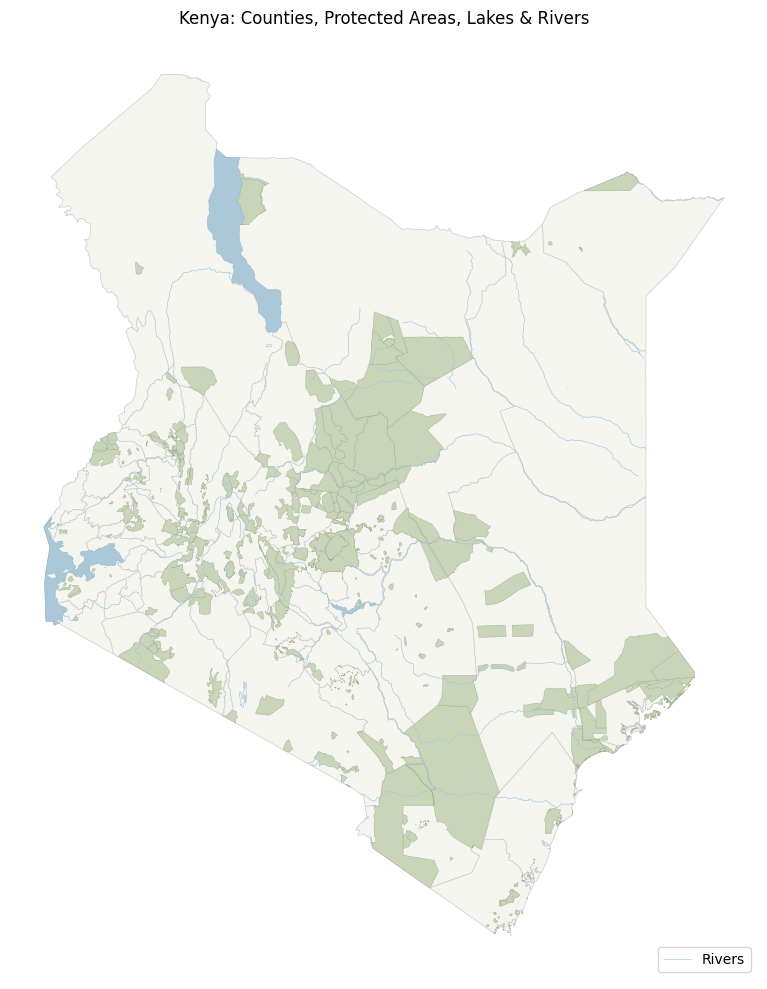

In [ ]:
# plot a kenya map with all the layers together

fig, ax = plt.subplots(figsize=(10, 10))

# Base layer: county borders

ke_counties.plot(ax=ax, color="#f5f5f0", edgecolor="#cccccc", linewidth=0.5)

# Protected areas

shp0_kenya.plot(ax=ax, color="#c8d5b9", edgecolor="#a0b090", linewidth=0.3, label='Protected Areas')
shp1_kenya.plot(ax=ax, color="#c8d5b9", edgecolor="#a0b090", linewidth=0.3)
shp2_kenya.plot(ax=ax, color="#c8d5b9", edgecolor="#a0b090", linewidth=0.3)

# Water features

ke_lakes.plot(ax=ax, color="#aac8d8", edgecolor="#88aabf", linewidth=0.3, label='Lakes')
ke_rivers.plot(ax=ax, color="#aac8d8", linewidth=0.5, label='Rivers')

plt.title('Kenya: Counties, Protected Areas, Lakes & Rivers')
plt.legend(loc='lower right')
plt.axis('off')
plt.tight_layout()
plt.show()

### Hydrological basins

## Compiling IUCN species data

In [46]:
# create the main df to which all others will be joined

simple_summary = pd.read_csv(r"./data/raw/iucn/simple_summary.csv", encoding='utf-8')

full_df = simple_summary.drop(columns=["infraType","infraName","infraAuthority","authority","criteriaVersion","scopes",'redlistCriteria'])

full_df.head()

,assessmentId,internalTaxonId,scientificName,kingdomName,phylumName,orderName,className,familyName,genusName,speciesName,redlistCategory,populationTrend
0,495630,10030,Hexanchus griseus,ANIMALIA,CHORDATA,HEXANCHIFORMES,CHONDRICHTHYES,HEXANCHIDAE,Hexanchus,griseus,Near Threatened,Decreasing
1,500969,11200,Lamna nasus,ANIMALIA,CHORDATA,LAMNIFORMES,CHONDRICHTHYES,LAMNIDAE,Lamna,nasus,Vulnerable,Decreasing
2,507158,232775771,Macrochelys temminckii,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,CHELYDRIDAE,Macrochelys,temminckii,Endangered,Decreasing
3,508210,12696,Malacochersus tornieri,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,TESTUDINIDAE,Malacochersus,tornieri,Critically Endangered,Decreasing
4,508612,12776,Mantella aurantiaca,ANIMALIA,CHORDATA,ANURA,AMPHIBIA,MANTELLIDAE,Mantella,aurantiaca,Endangered,Decreasing


### Replace with function

In [ ]:
# read all other relevant files

all_other_fields = pd.read_csv(r"./data/raw/iucn/all_other_fields.csv", encoding='utf-8')
habitats = pd.read_csv(r"./data/raw/iucn/habitats.csv", encoding='utf-8')
threats = pd.read_csv(r"./data/raw/iucn/threats.csv", encoding='utf-8')
usetrade = pd.read_csv(r"./data/raw/iucn/usetrade.csv", encoding='utf-8')
conservation_needed = pd.read_csv(r"./data/raw/iucn/conservation_needed.csv", encoding='utf-8')
research_needed = pd.read_csv(r"./data/raw/iucn/research_needed.csv", encoding='utf-8')
countries = pd.read_csv(r"./data/raw/iucn/countries.csv", encoding='utf-8')

# select the columns from each additional csv and rename it for merging

range = all_other_fields[['internalTaxonId', 'AOO.range', 'EOO.range', 'ElevationLower.limit', 'ElevationUpper.limit']]

habitats = habitats[['internalTaxonId', 'code', 'name']].rename(columns={'code':'habitatCode', 'name':'habitatName'})

threats = threats[['internalTaxonId', 'code', 'name', 'stressCode', 'stressName']].rename(columns={'code':'threatCode','name':'threatName'})

usetrade = usetrade[['internalTaxonId', 'code', 'name']].rename(columns={'code':'useCode', 'name':'useName'})

conservation_needed = conservation_needed[['internalTaxonId', 'code', 'name']].rename(columns={'code':'conservationNeededCode', 'name':'conservationNeededName'})

research_needed = research_needed[['internalTaxonId', 'code', 'name']].rename(columns={'code':'researchNeededCode','name':'researchNeededName'})

countries = countries[['internalTaxonId', 'code', 'name', 'presence', 'origin', 'seasonality']].rename(columns={'code':'countryCode', 'name':'countryName'})

In [ ]:
# save filtered tables to csv

range.to_csv('./data/processed/range.csv', index=False)
habitats.to_csv('./data/processed/habitats.csv', index=False)
threats.to_csv('./data/processed/threats.csv', index=False)
usetrade.to_csv('./data/processed/uses.csv', index=False)
conservation_needed.to_csv('./data/processed/conservation_needed.csv', index=False)
research_needed.to_csv('./data/processed/research_needed.csv', index=False)
countries.to_csv('./data/processed/countries.csv', index=False)

In [ ]:
full_df = full_df.merge(right=range, on=['internalTaxonId'], how='left')
full_df = full_df.merge(right=habitats, on=['internalTaxonId'], how='left')
full_df = full_df.merge(right=threats, on=['internalTaxonId'], how='left')
full_df = full_df.merge(right=usetrade, on=['internalTaxonId'], how='left')
full_df = full_df.merge(right=conservation_needed, on=['internalTaxonId'], how='left')
full_df = full_df.merge(right=research_needed, on=['internalTaxonId'], how='left')

## Missingness

<Axes: >

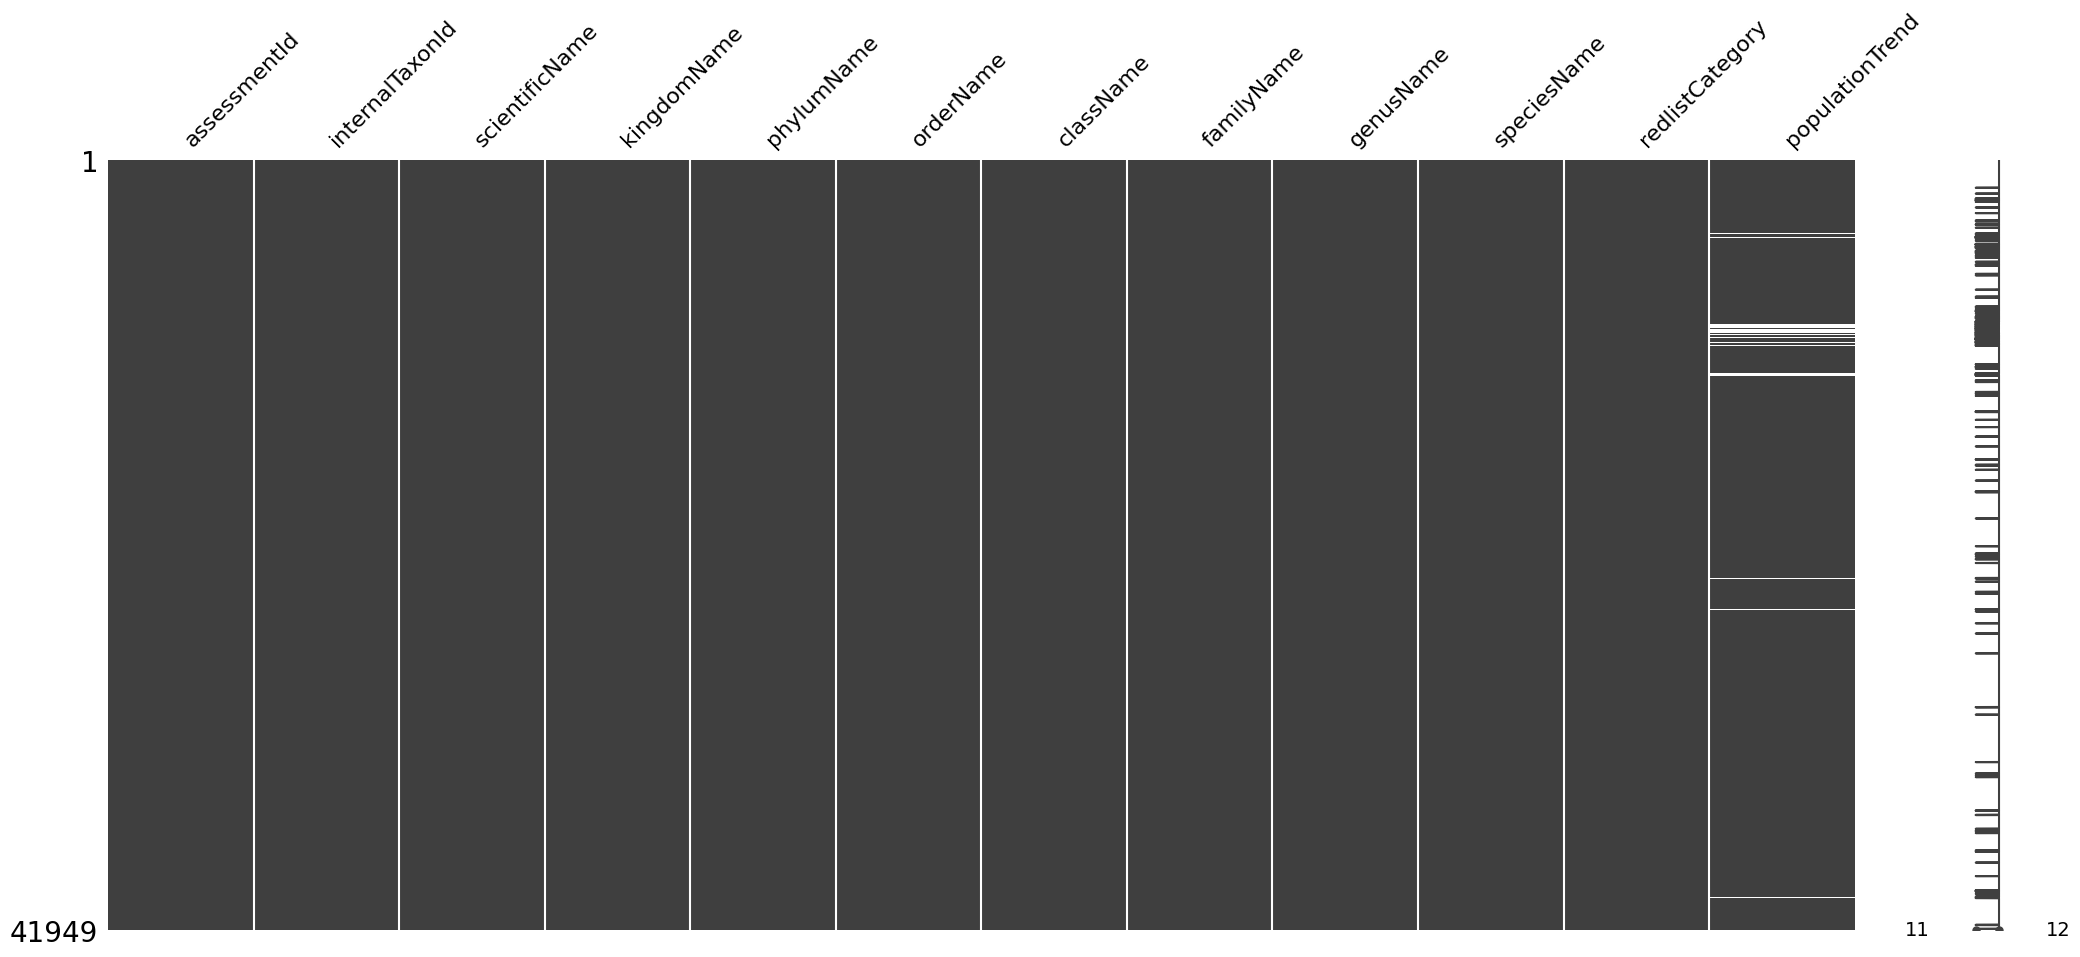

In [53]:
mn.matrix(full_df)

In [50]:
full_df['populationTrend'].unique()

# when addressing missingness, fill nan values with "Unknown"

<StringArray>
['Decreasing', 'Unknown', 'Stable', 'Increasing', nan]
Length: 5, dtype: str

<Axes: >

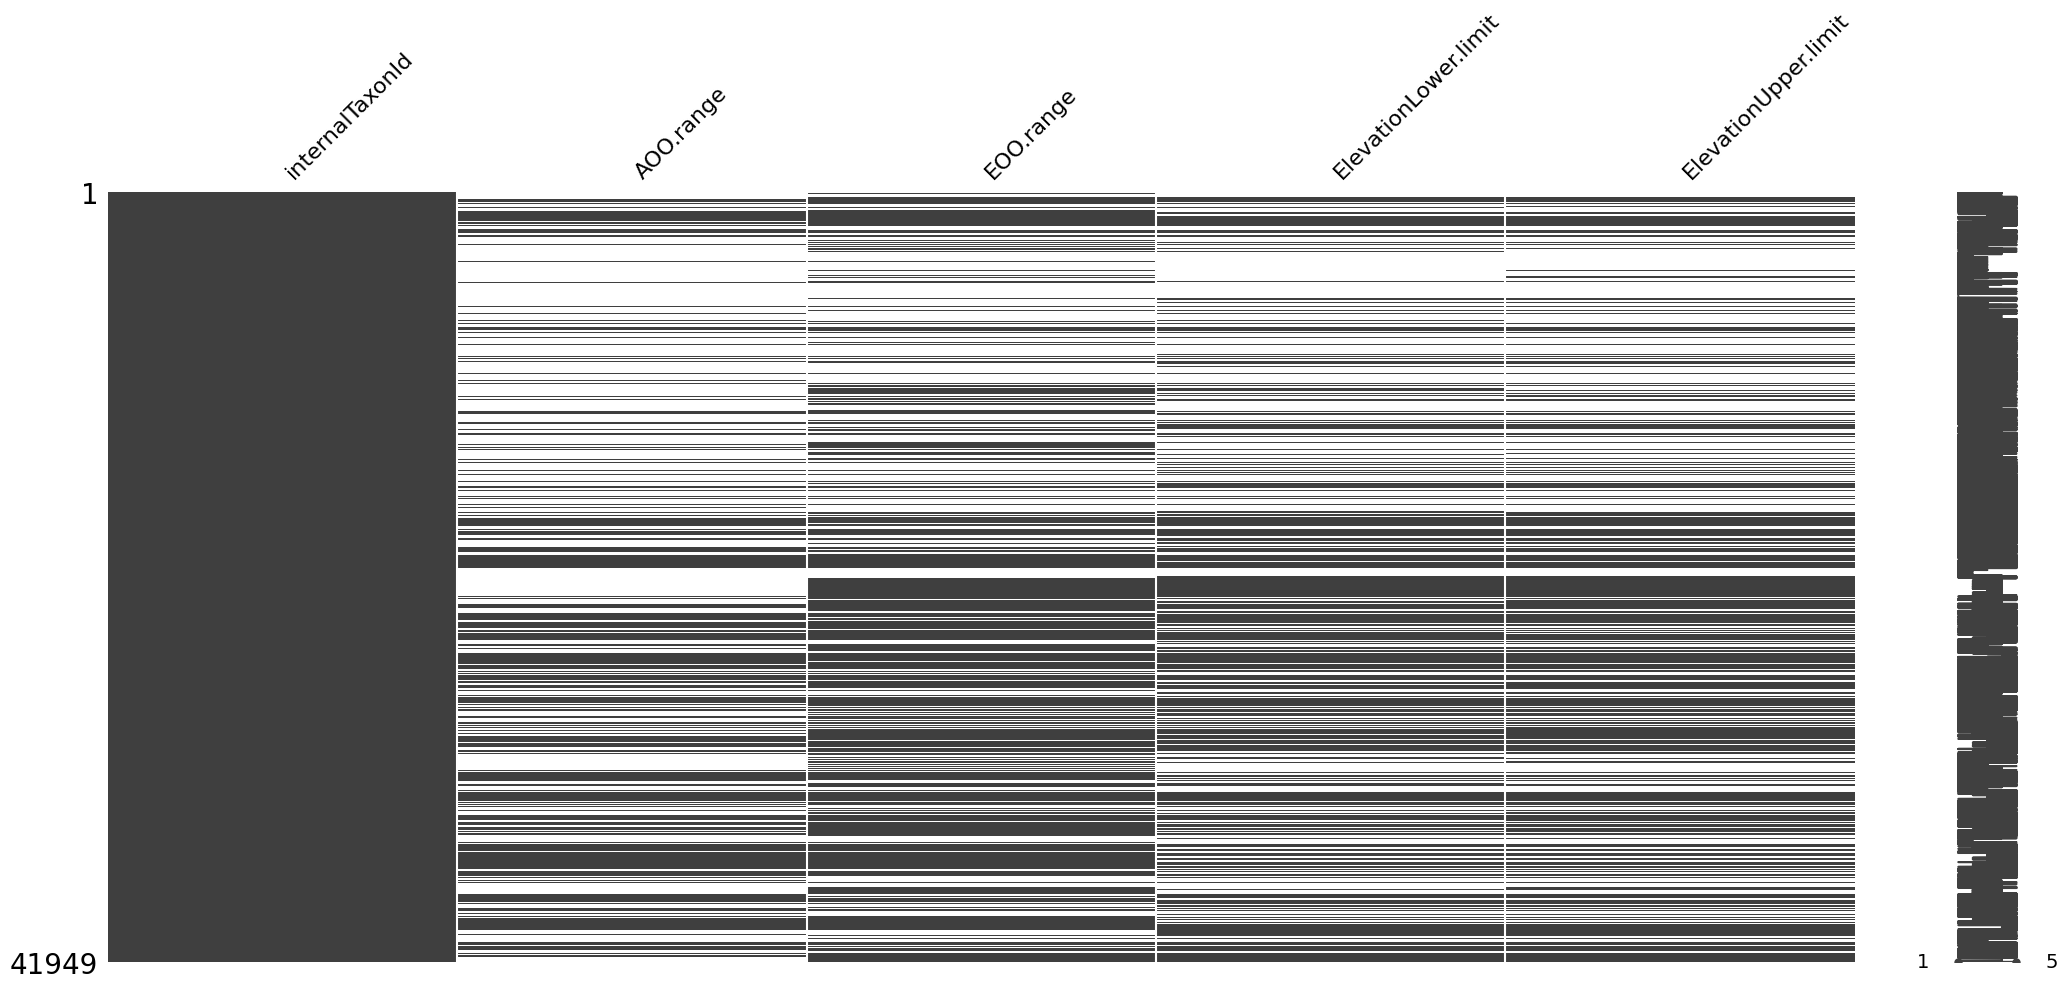

In [75]:
mn.matrix(range)

<Axes: >

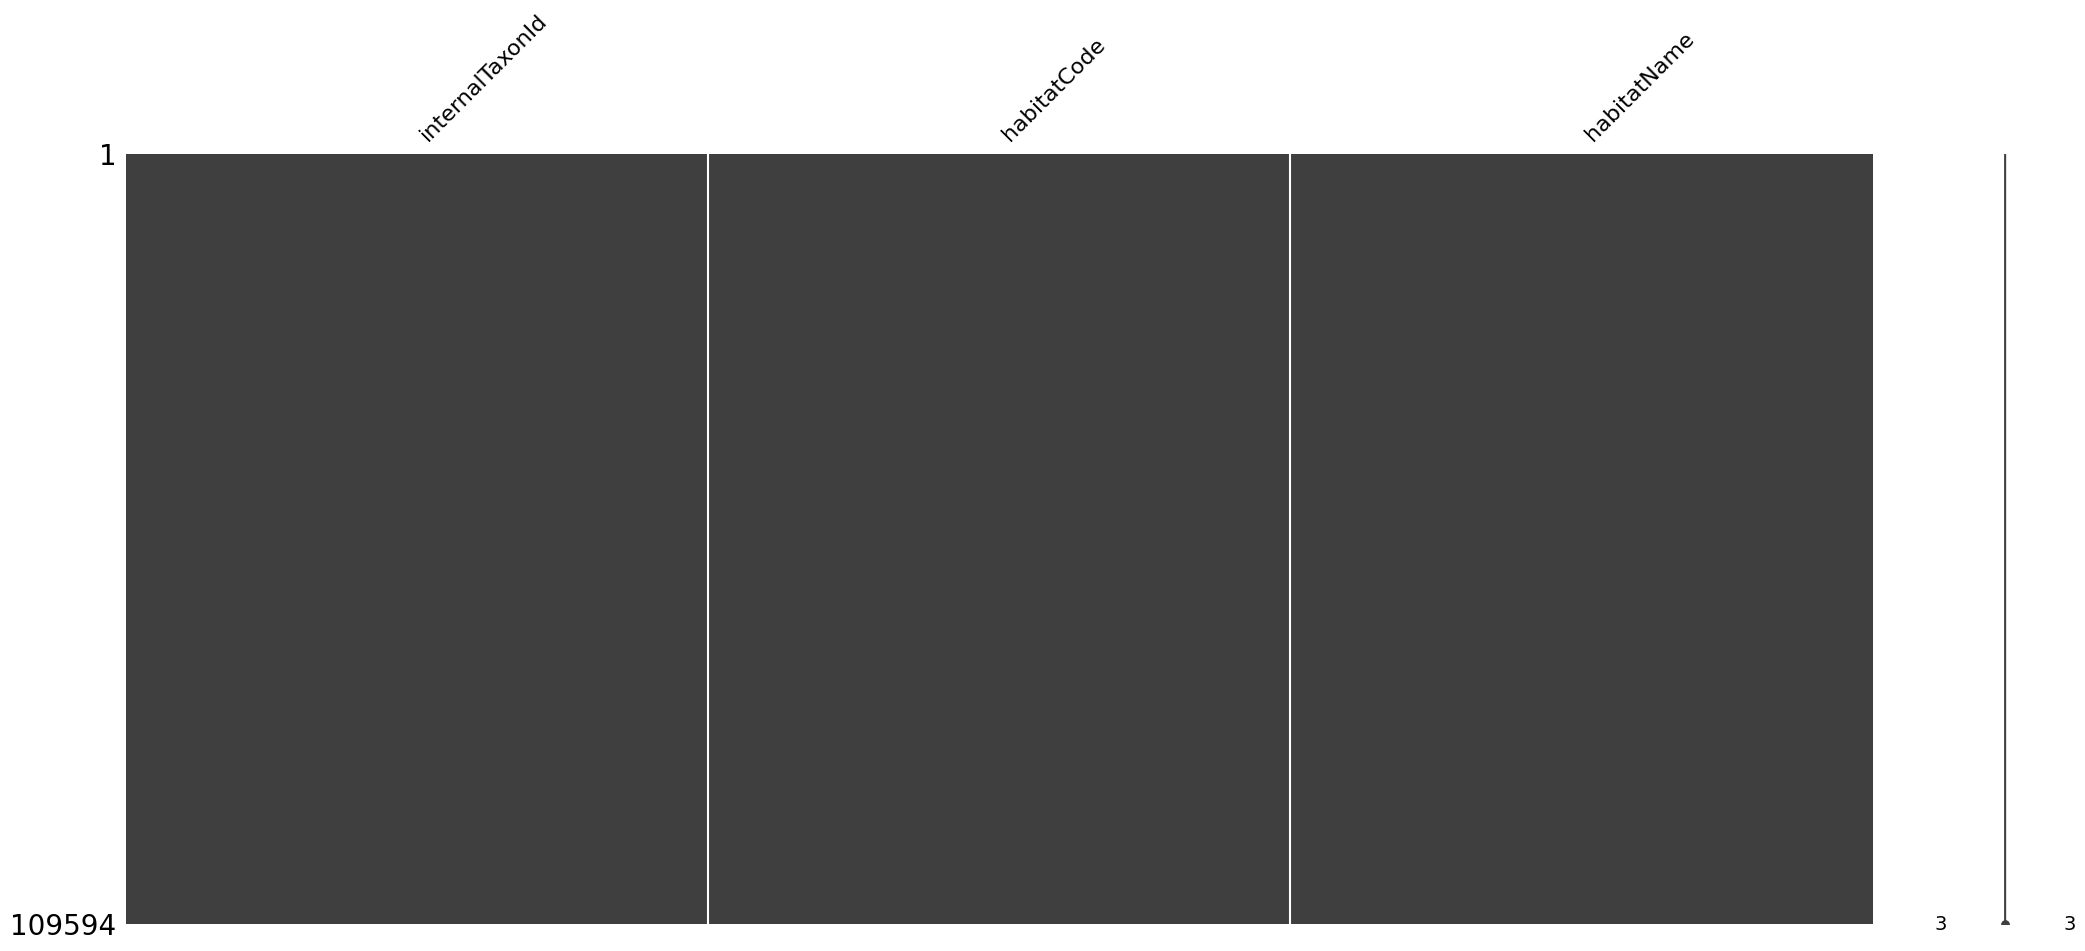

In [76]:
mn.matrix(habitats)

<Axes: >

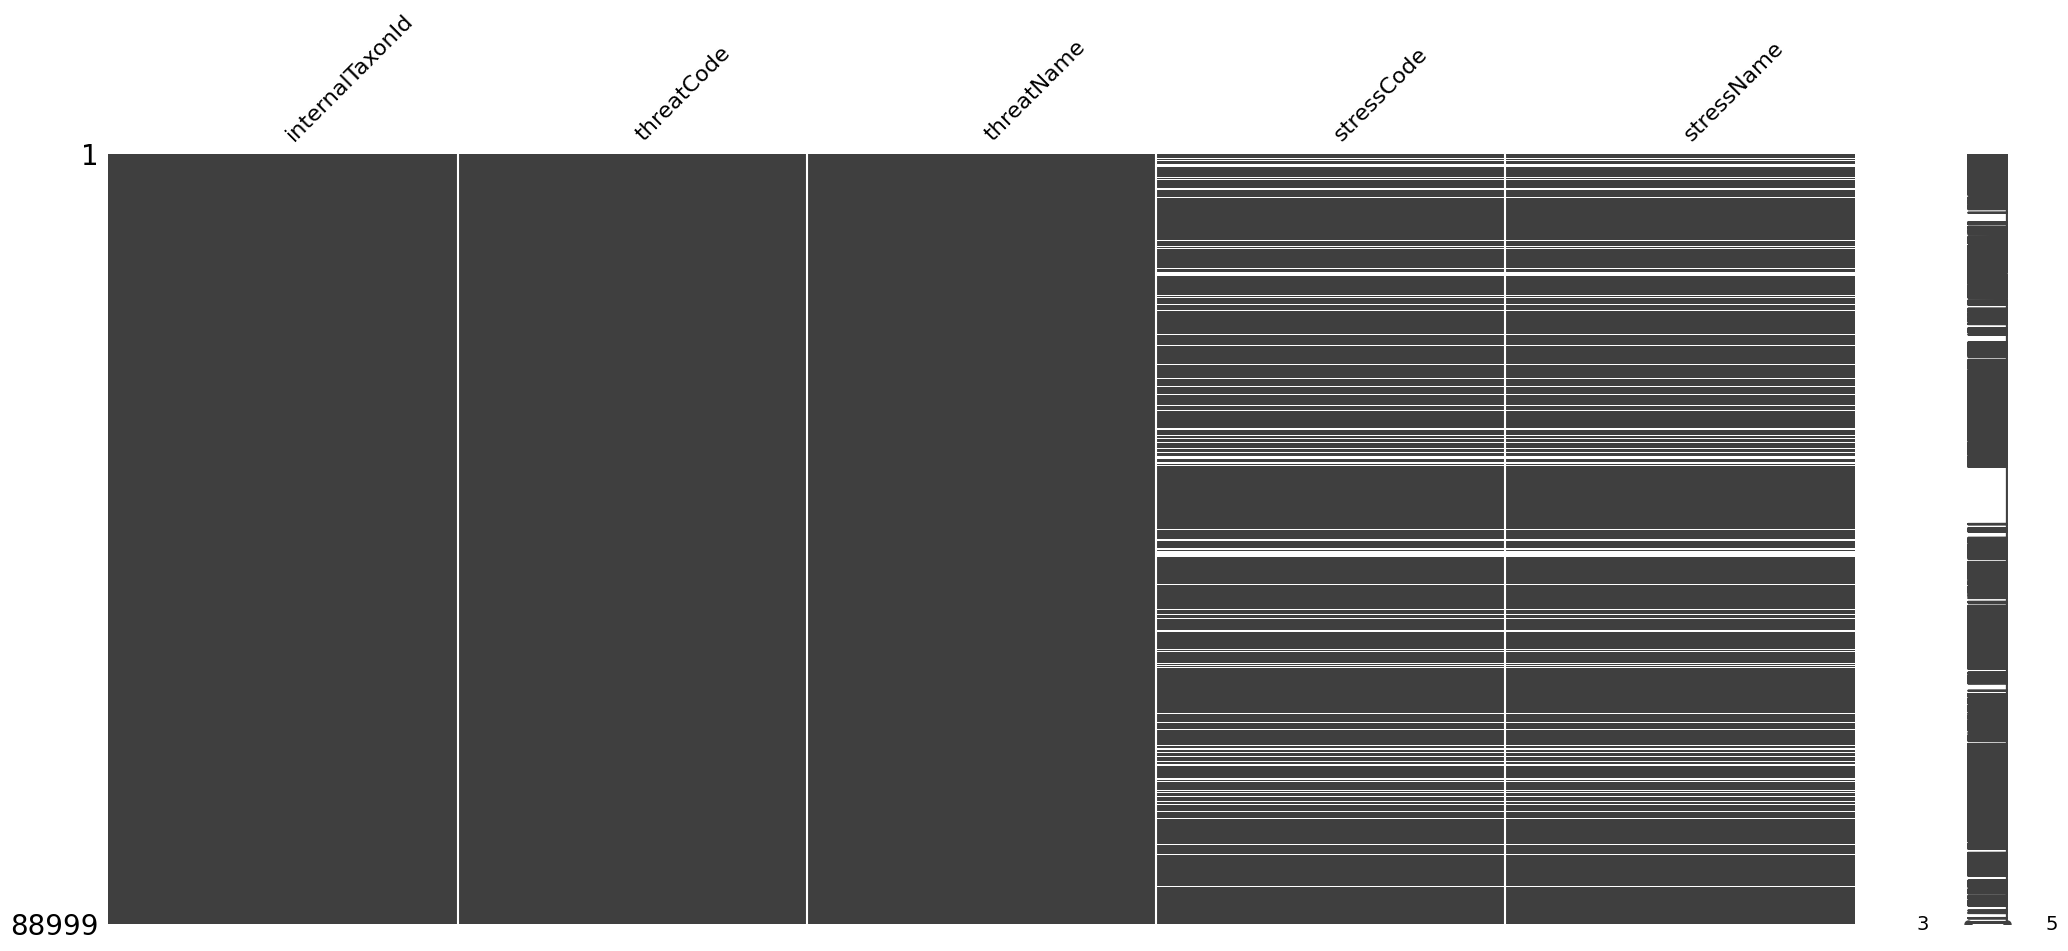

In [80]:
mn.matrix(threats)

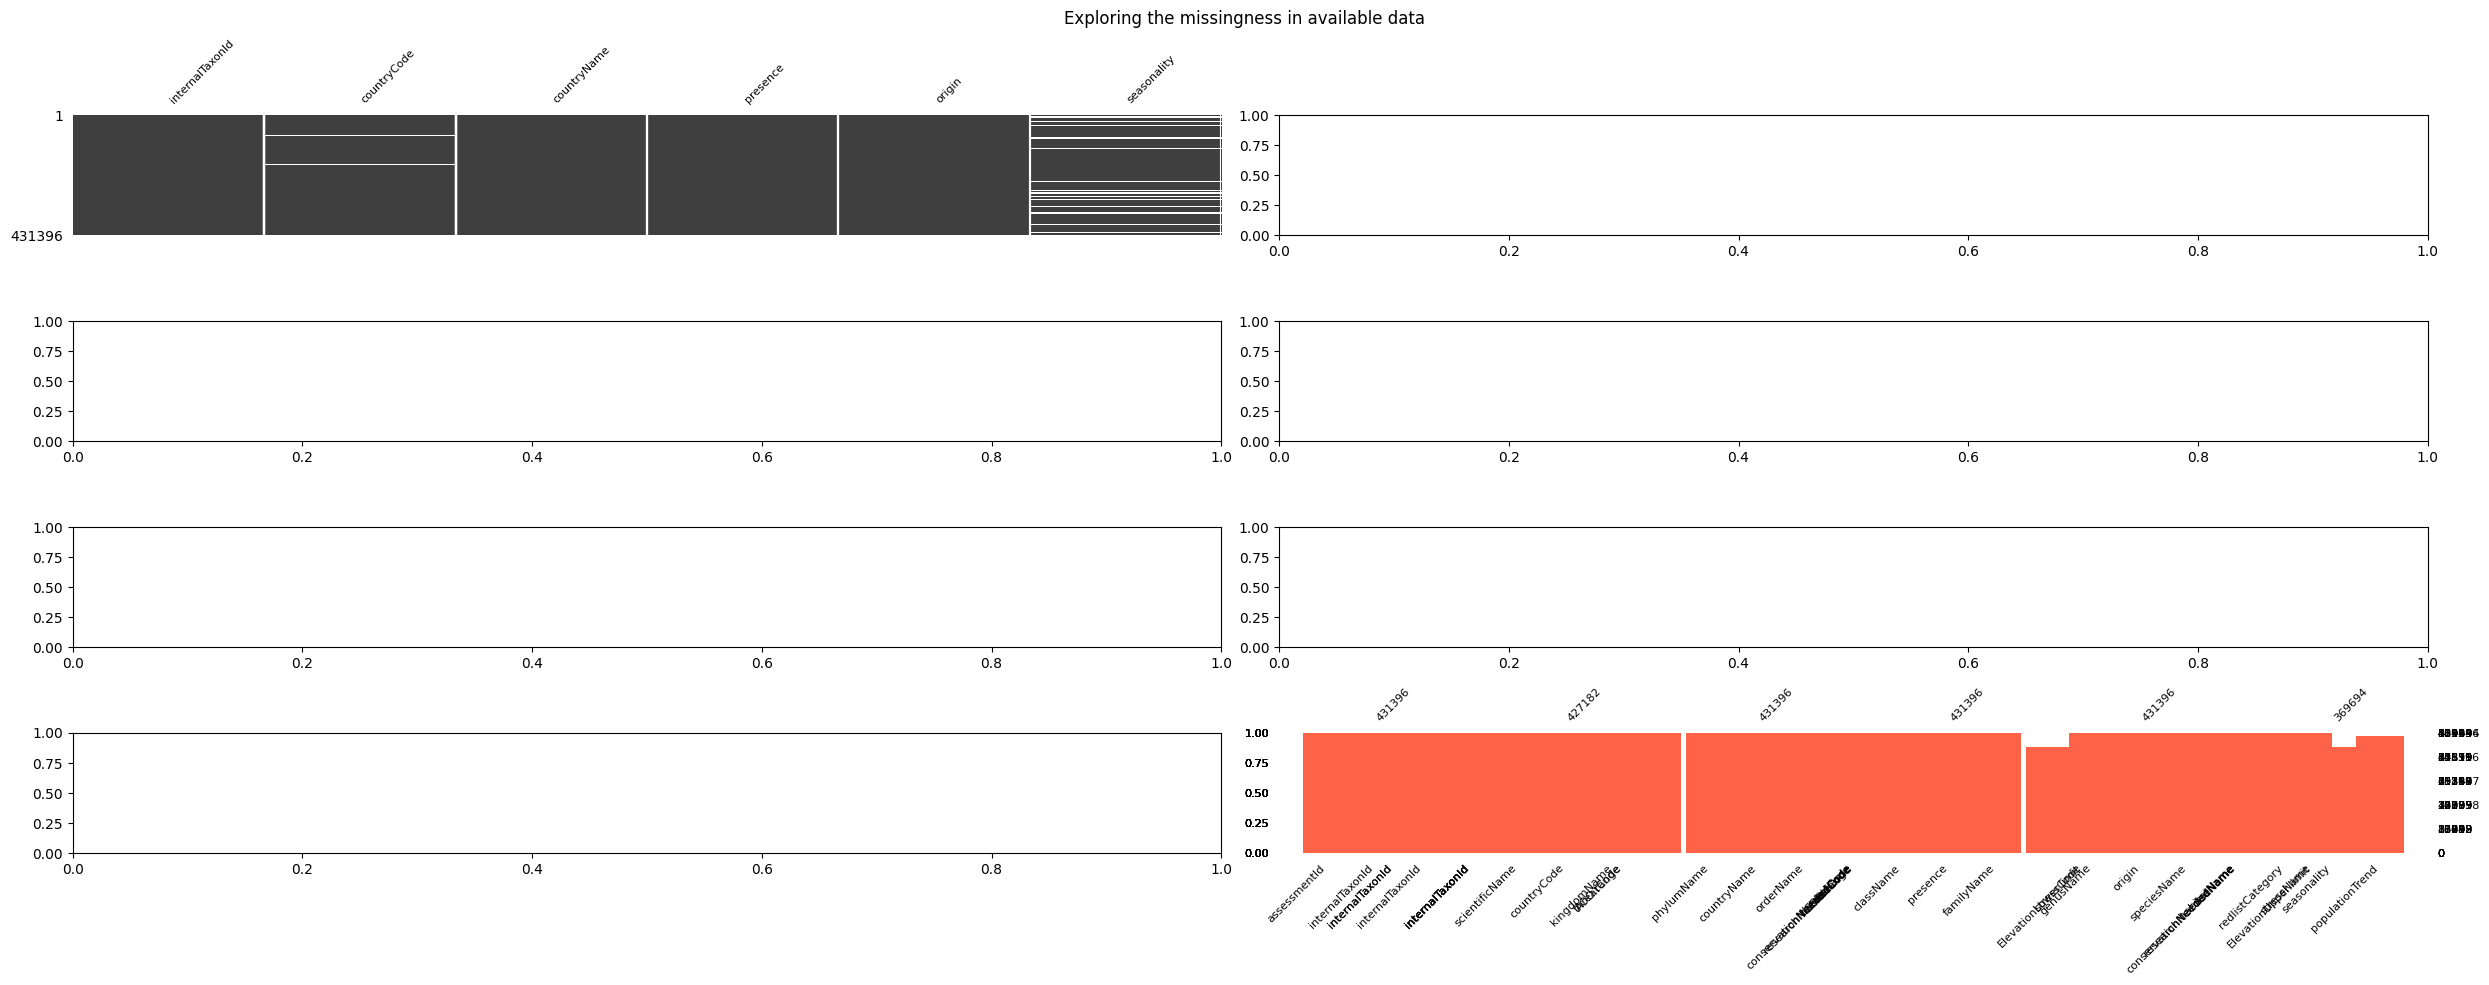

In [82]:
all_tables = [full_df, range, habitats, threats, usetrade, conservation_needed, research_needed, countries]

fig, axes = plt.subplots(4, 2, figsize=(10,20))
axes = axes.flatten()

for i, table in enumerate(all_tables):
    matrix_df = mn.matrix(table, ax=axes[0], sparkline=False, fontsize=8)
    bar_df = mn.bar(table, color='tomato', fontsize=8)

plt.suptitle('Exploring the missingness in available data', fontsize=12)
plt.tight_layout()
plt.show()